# 数据集预处理
针对单个数据集进行严格的：
- 设置随机种子
- 样本筛选
- 细胞质控
- 去除环境污染（是否需要？）
- 保存质控后数据至'UC/scRNA-seq_data/03_qc_filtered'文件夹
- 批次效应查看
- 降维聚类结果
- 处理异常细胞群
- 区分主要谱系

# 文件说明
- **文件名**: 4_GSE116222_qc.h5ad 
- **存放位置**: 坚果云  `UC/scRNA-seq_data/03_qc_filtered/`  
- **生成日期**: 2025-11-4 
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/1.2_qc_filtered/4_GSE116222.ipynb  
- **内容说明**: 完成了针对单个数据的预处理工作，包括样本排除、细胞质控，并查看了样本间的批次效应。  

In [1]:
import numpy as np
import random
np.random.seed(42)
random.seed(42)

In [2]:
import scanpy as sc
#sc.settings.verbosity = 1
print(sc.__version__)

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


1.11.4


## 读取数据
GSE116222数据集：
- 结肠组织 上皮细胞
- 6UC，3HC

In [3]:
adata = sc.read_h5ad('/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/02_sample_merge/4_GSE116222.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 11113 × 22609
    obs: 'n_genes', 'group', 'id', 'GSM', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'n_cells', 'mt'
    uns: 'REFERENCE_MANU', 'scrublet', 'status', 'status_args'

In [5]:
adata.obs.head()

,n_genes,group,id,GSM,nUMIs,mito_perc,detected_genes,cell_complexity,passing_mt,passing_nUMIs,passing_ngenes,doublet_score,predicted_doublet
AAACCTGGTAATCGTC-A1,2110,A1,HC11,GSM3214203,1990.073433,0.0,2110,1.060262,True,True,True,0.030748,False
AAACGGGAGCTTTGGT-A1,1353,A1,HC11,GSM3214203,2182.804342,0.0,1353,0.619845,True,True,True,0.006236,False
AAACGGGTCTGGTATG-A1,806,A1,HC11,GSM3214203,1695.304230,0.0,806,0.475431,True,True,True,0.008624,False
AAAGTAGAGAACTGTA-A1,1184,A1,HC11,GSM3214203,2023.887201,0.0,1184,0.585013,True,True,True,0.029292,False
AAAGTAGCAGGGAGAG-A1,1538,A1,HC11,GSM3214203,1955.692365,0.0,1538,0.786422,True,True,True,0.007257,False


## 处理细胞标签及分组

In [6]:
adata.obs.drop(columns=['group'], inplace=True)

In [7]:
adata.obs.head()

,n_genes,id,GSM,nUMIs,mito_perc,detected_genes,cell_complexity,passing_mt,passing_nUMIs,passing_ngenes,doublet_score,predicted_doublet
AAACCTGGTAATCGTC-A1,2110,HC11,GSM3214203,1990.073433,0.0,2110,1.060262,True,True,True,0.030748,False
AAACGGGAGCTTTGGT-A1,1353,HC11,GSM3214203,2182.804342,0.0,1353,0.619845,True,True,True,0.006236,False
AAACGGGTCTGGTATG-A1,806,HC11,GSM3214203,1695.304230,0.0,806,0.475431,True,True,True,0.008624,False
AAAGTAGAGAACTGTA-A1,1184,HC11,GSM3214203,2023.887201,0.0,1184,0.585013,True,True,True,0.029292,False
AAAGTAGCAGGGAGAG-A1,1538,HC11,GSM3214203,1955.692365,0.0,1538,0.786422,True,True,True,0.007257,False


In [8]:
# 提取分组信息
import pandas as pd
adata.obs['group'] = adata.obs['id'].str.extract(r'([A-Za-z]+)', expand=False)
print(adata.obs[['id', 'group']].head())

                       id group
AAACCTGGTAATCGTC-A1  HC11    HC
AAACGGGAGCTTTGGT-A1  HC11    HC
AAACGGGTCTGGTATG-A1  HC11    HC
AAAGTAGAGAACTGTA-A1  HC11    HC
AAAGTAGCAGGGAGAG-A1  HC11    HC


`.obs`当中只保留GSM信息和分组信息

In [9]:
adata.obs.drop(columns=['id'], inplace=True)
print(adata.obs.head())

                     n_genes         GSM        nUMIs  mito_perc  \
AAACCTGGTAATCGTC-A1     2110  GSM3214203  1990.073433        0.0   
AAACGGGAGCTTTGGT-A1     1353  GSM3214203  2182.804342        0.0   
AAACGGGTCTGGTATG-A1      806  GSM3214203  1695.304230        0.0   
AAAGTAGAGAACTGTA-A1     1184  GSM3214203  2023.887201        0.0   
AAAGTAGCAGGGAGAG-A1     1538  GSM3214203  1955.692365        0.0   

                     detected_genes  cell_complexity  passing_mt  \
AAACCTGGTAATCGTC-A1            2110         1.060262        True   
AAACGGGAGCTTTGGT-A1            1353         0.619845        True   
AAACGGGTCTGGTATG-A1             806         0.475431        True   
AAAGTAGAGAACTGTA-A1            1184         0.585013        True   
AAAGTAGCAGGGAGAG-A1            1538         0.786422        True   

                     passing_nUMIs  passing_ngenes  doublet_score  \
AAACCTGGTAATCGTC-A1           True            True       0.030748   
AAACGGGAGCTTTGGT-A1           True          

In [10]:
adata.obs['group'].value_counts()

group
UC    6888
HC    4225
Name: count, dtype: int64

## 样本质量查看

In [11]:
adata.obs['GSM'].value_counts()

GSM
GSM3214209    2135
GSM3214205    1972
GSM3214208    1720
GSM3214206    1609
GSM3214207    1264
GSM3214204    1030
GSM3214201     532
GSM3214203     481
GSM3214202     370
Name: count, dtype: int64

In [12]:
sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])

print(sample_quality_stats)

                n_genes                                nUMIs              \
                   mean          std  min   max         mean         std   
GSM                                                                        
GSM3214201  1360.599624   534.758685  319  3428  2019.817927  487.273834   
GSM3214202  1617.540541   928.559017  491  5753  2096.439253  445.102356   
GSM3214203  1793.239085   839.106605  539  4728  2110.849806  348.772225   
GSM3214204  2485.733010  1397.891471  255  5546  2580.961103  611.586492   
GSM3214205  1809.148073   771.887691  473  3979  2291.156735  454.164337   
GSM3214206  1741.221255   755.639884  518  4153  2233.667056  406.757447   
GSM3214207  1746.333861   939.738881  358  4340  2176.033724  543.454473   
GSM3214208  1624.783140   840.731320  453  4404  2059.552846  465.946395   
GSM3214209  1484.900703   621.284619  472  3788  2029.520050  380.155467   

                                         mito_perc                           
         

/tmp/ipykernel_7887/2761774101.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])


## 细胞质控

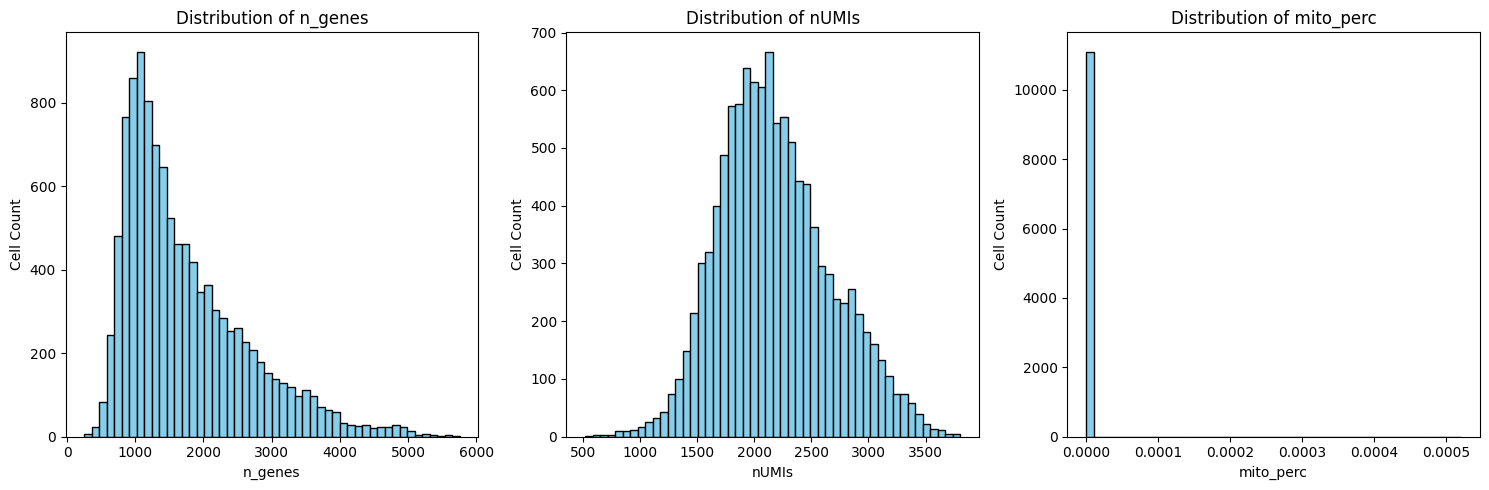

In [13]:
import matplotlib.pyplot as plt

# 选择要可视化的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 绘制各个指标的直方图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# 绘制每个质量控制指标的直方图
for i, metric in enumerate(qc_metrics):
    ax[i].hist(adata.obs[metric], bins=50, color='skyblue', edgecolor='black')
    ax[i].set_title(f'Distribution of {metric}')
    ax[i].set_xlabel(metric)
    ax[i].set_ylabel('Cell Count')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


/tmp/ipykernel_7887/2077234365.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels, rotation=45, ha='right')
/tmp/ipykernel_7887/2077234365.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels, rotation=45, ha='right')
/tmp/ipykernel_7887/2077234365.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels, rotation=45, ha='right')


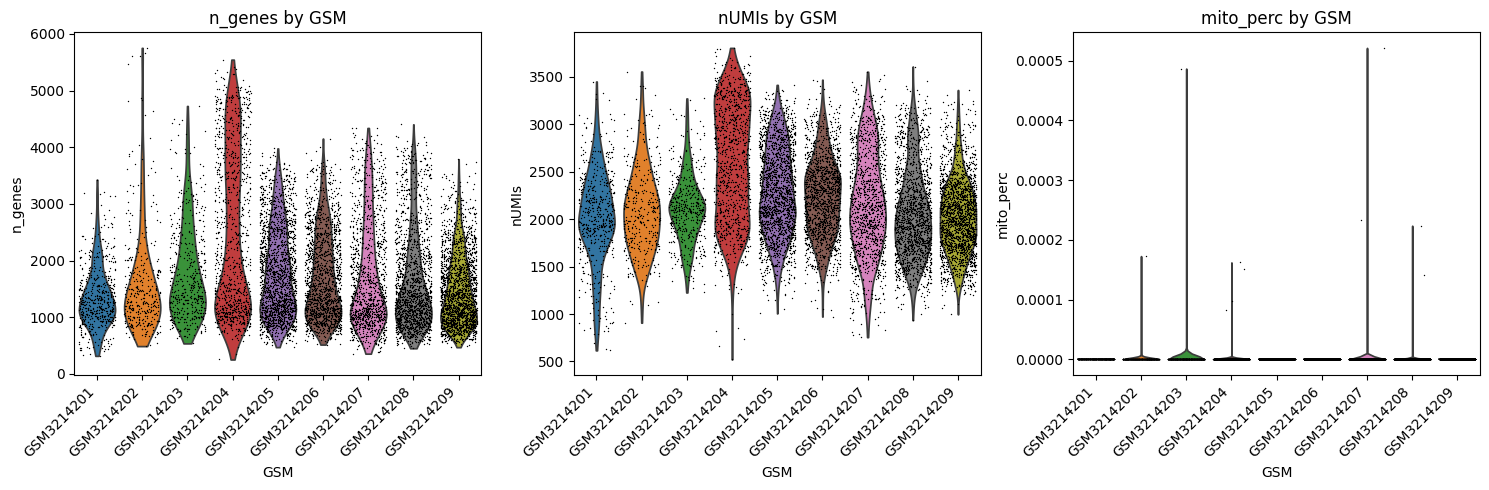

In [14]:
# 设置绘图风格
sc.settings.verbosity = 0  # 简化日志输出

# 选择要绘制的小提琴图的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 按照样本（GSM）绘制小提琴图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(qc_metrics):
    sc.pl.violin(adata, keys=metric, groupby='GSM', ax=ax[i], stripplot=True, jitter=0.4, show=False)
    ax[i].set_title(f'{metric} by GSM')
    ax[i].set_ylabel(f'{metric}')
    
    # 获取当前的x轴标签
    labels = ax[i].get_xticklabels()
    # 旋转标签并调整对齐方式（末尾对齐）
    ax[i].set_xticklabels(labels, rotation=45, ha='right')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


### 严格细胞质控标准
- min_genes = 200          # 最少基因数
- max_genes = 4000         # 最多基因数
- min_umis = 500           # 最少UMI数量
- max_umis = 20000         # 最多UMI数量
- max_mito_perc = 10       # 线粒体基因百分比最大值

In [ ]:
# 设置阈值
min_genes = 200          # 最少基因数
max_genes = 6000         # 最多基因数
min_umis = 500           # 最少UMI数量
max_umis = 20000        # 最多UMI数量
max_mito_perc = 0.1       # 线粒体基因百分比最大值

# 根据阈值进行过滤
adata = adata[(adata.obs['n_genes'] > min_genes) & 
              (adata.obs['n_genes'] < max_genes) &
              (adata.obs['nUMIs'] > min_umis) &
              (adata.obs['nUMIs'] < max_umis) &
              (adata.obs['mito_perc'] < max_mito_perc), :]

# 输出过滤后的细胞数
print(f'Number of cells after filtering: {adata.n_obs}')

Number of cells after filtering: 11113


## 保存质控后数据


In [16]:
import os
output_dir = "/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/03_qc_filtered/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "4_GSE116222_qc.h5ad"), compression='gzip')

## 降维聚类

In [17]:
import omicverse as ov
ov.plot_set(dpi=50)
ov.settings.verbose = 1 
ov.settings.cpu_gpu_mixed_init()

🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

CPU-GPU mixed mode activated


结肠组织上皮细胞，所以选取1000个高变基因  
取resolution=0.2

In [18]:
# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=1000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.2)

Begin robust gene identification
After filtration, 22609/22609 genes are kept.     Among 22609 genes, 22609 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell
The following highly-expressed genes are not considered during normalization factor computation:
[]
    finished (0:00:02)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 17.635001182556152 seconds.
End of size normalization: shiftlog and HVGs selection pearson
🚀 Using GPU to calculate PCA...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    |||-------

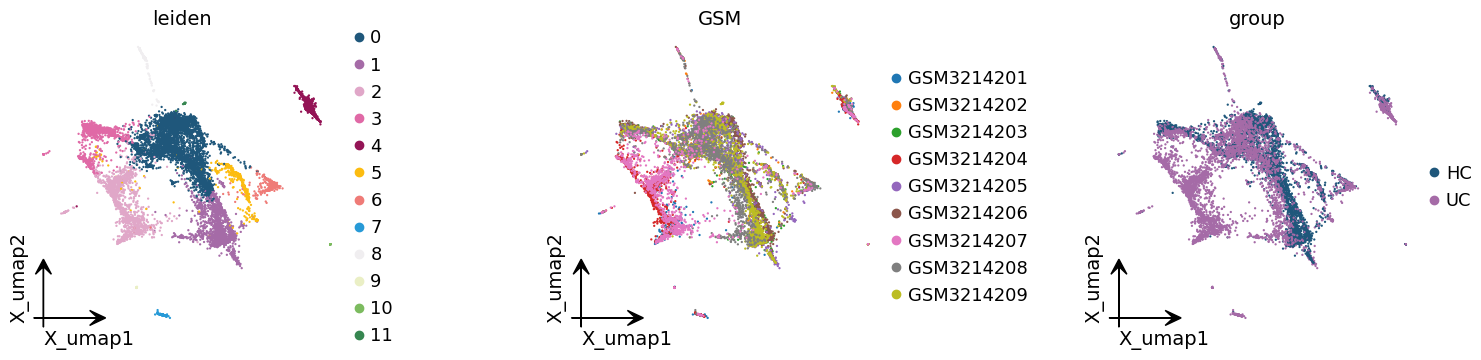

In [19]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.5)

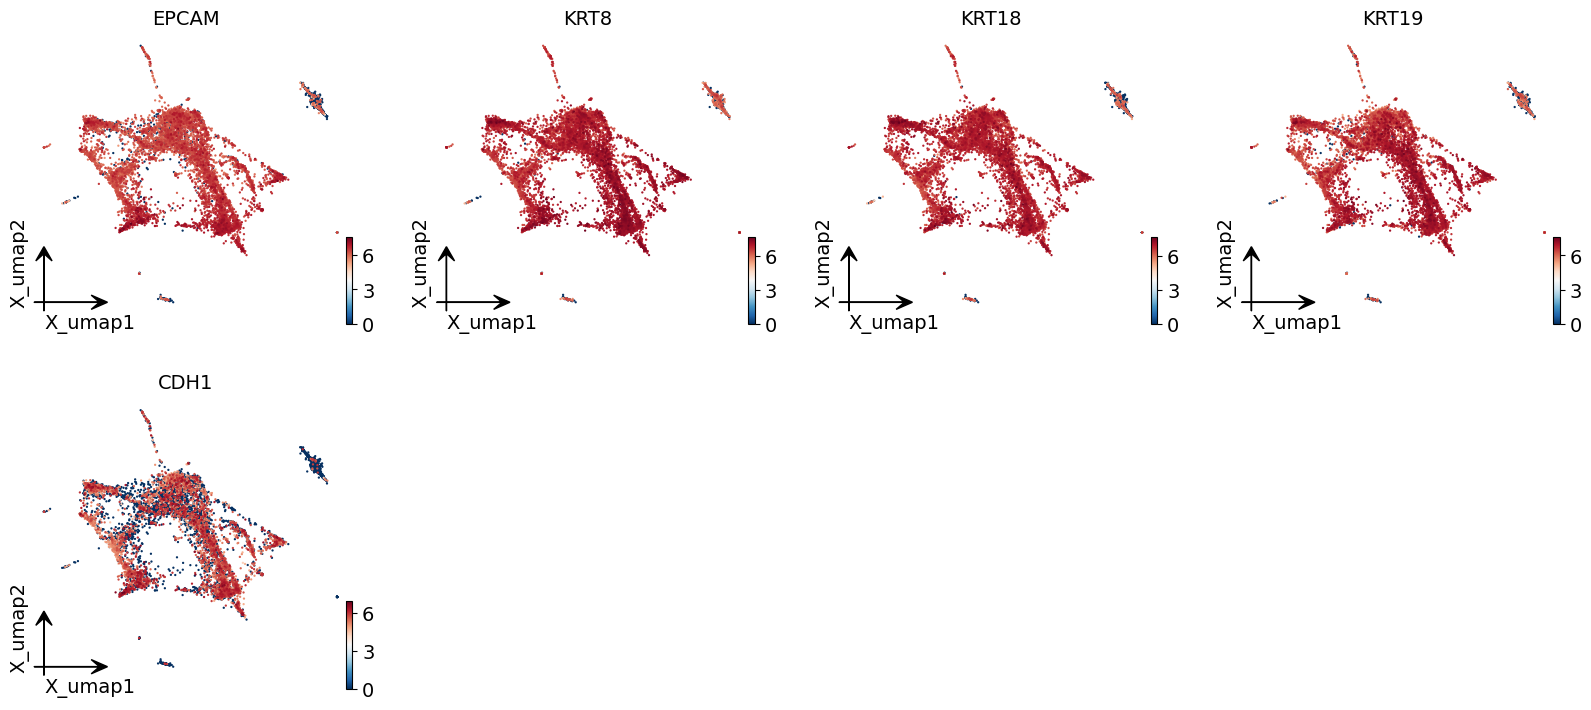

In [20]:
# 上皮谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['EPCAM', 'KRT8', 'KRT18', 'KRT19', 'CDH1'], # CLDN1
                frameon='small')

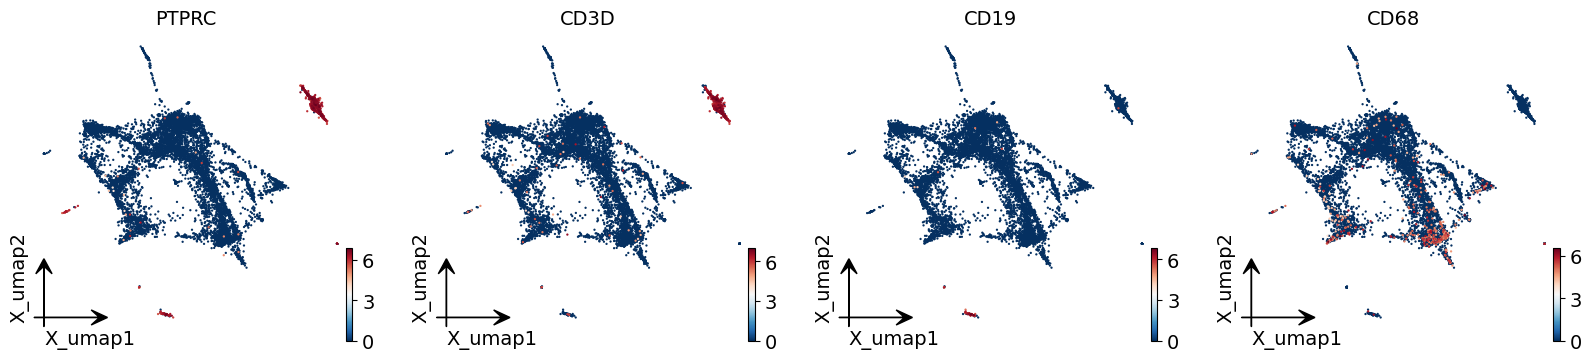

In [21]:
# 免疫谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC', 'CD3D', 'CD19', 'CD68'], 
                frameon='small')

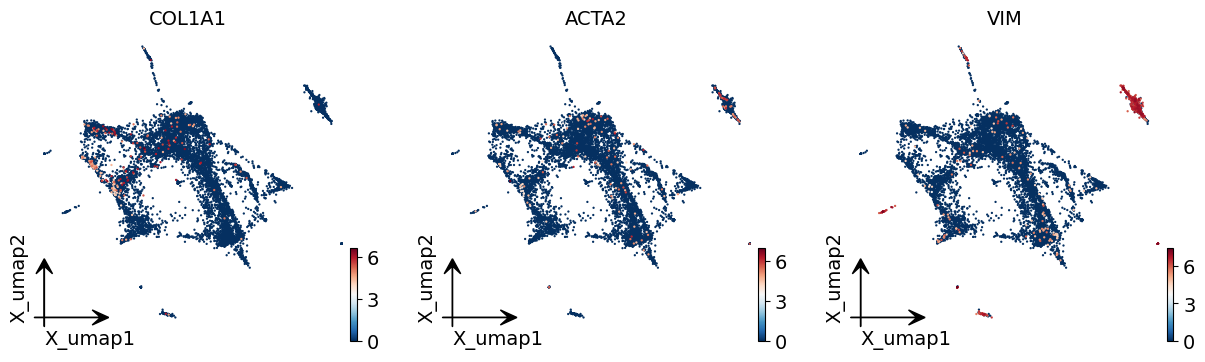

In [23]:
# 基质谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['COL1A1', 'ACTA2', 'VIM'],  # 'FAP'
                frameon='small')

## 去除批次效应
按样本去除批次，看看是否效果会更好

使用`harmony`

In [30]:
ov.single.batch_correction(adata,
                           batch_key='GSM', # 去批次分组标签
                           methods='harmony',
                           n_pcs=50)
                           
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='X_harmony')

ov.pp.umap(adata)

ov.pp.leiden(adata,resolution=0.2)

...Begin using harmony to correct batch effect


2025-11-04 13:16:38,206 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-11-04 13:16:40,113 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-04 13:16:40,153 - harmonypy - INFO - Iteration 1 of 10
2025-11-04 13:16:42,046 - harmonypy - INFO - Iteration 2 of 10
2025-11-04 13:16:44,082 - harmonypy - INFO - Iteration 3 of 10
2025-11-04 13:16:46,207 - harmonypy - INFO - Iteration 4 of 10
2025-11-04 13:16:48,268 - harmonypy - INFO - Iteration 5 of 10
2025-11-04 13:16:50,306 - harmonypy - INFO - Converged after 5 iterations


🖥️ Using Scanpy CPU to calculate neighbors...
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
🔍 [2025-11-04 13:16:51] Running UMAP in 'cpu-gpu-mixed' mode...
🚀 Using torch GPU to calculate UMAP...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    ||||-------------------------- 2277/16311 MiB (14.0%)
computing UMAP🚀
    finished ✅: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)
✅ UMAP completed successfully.
🖥️ Using Scanpy CPU Leiden...
running Leiden clustering
    finished: found 12 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:03)


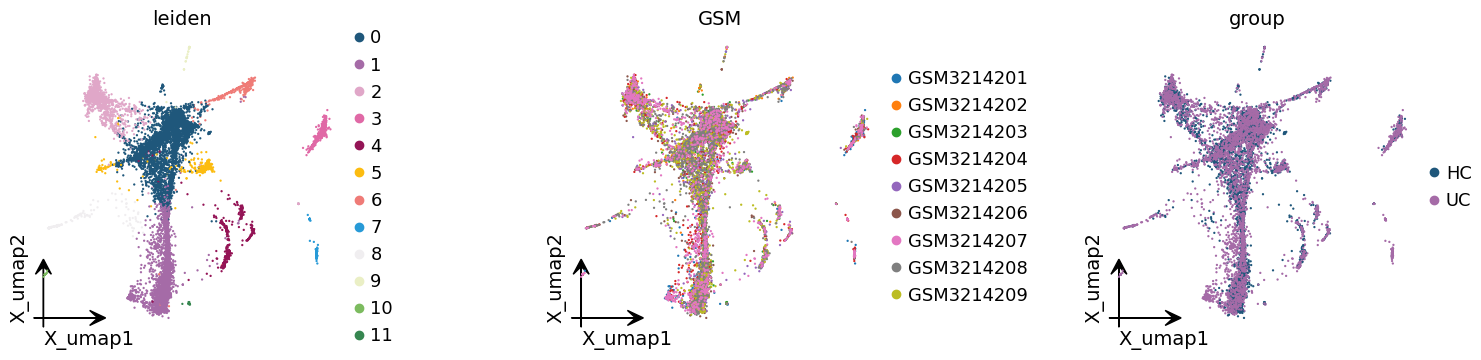

In [31]:
# 可视化查看去除批次效应后聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.5)

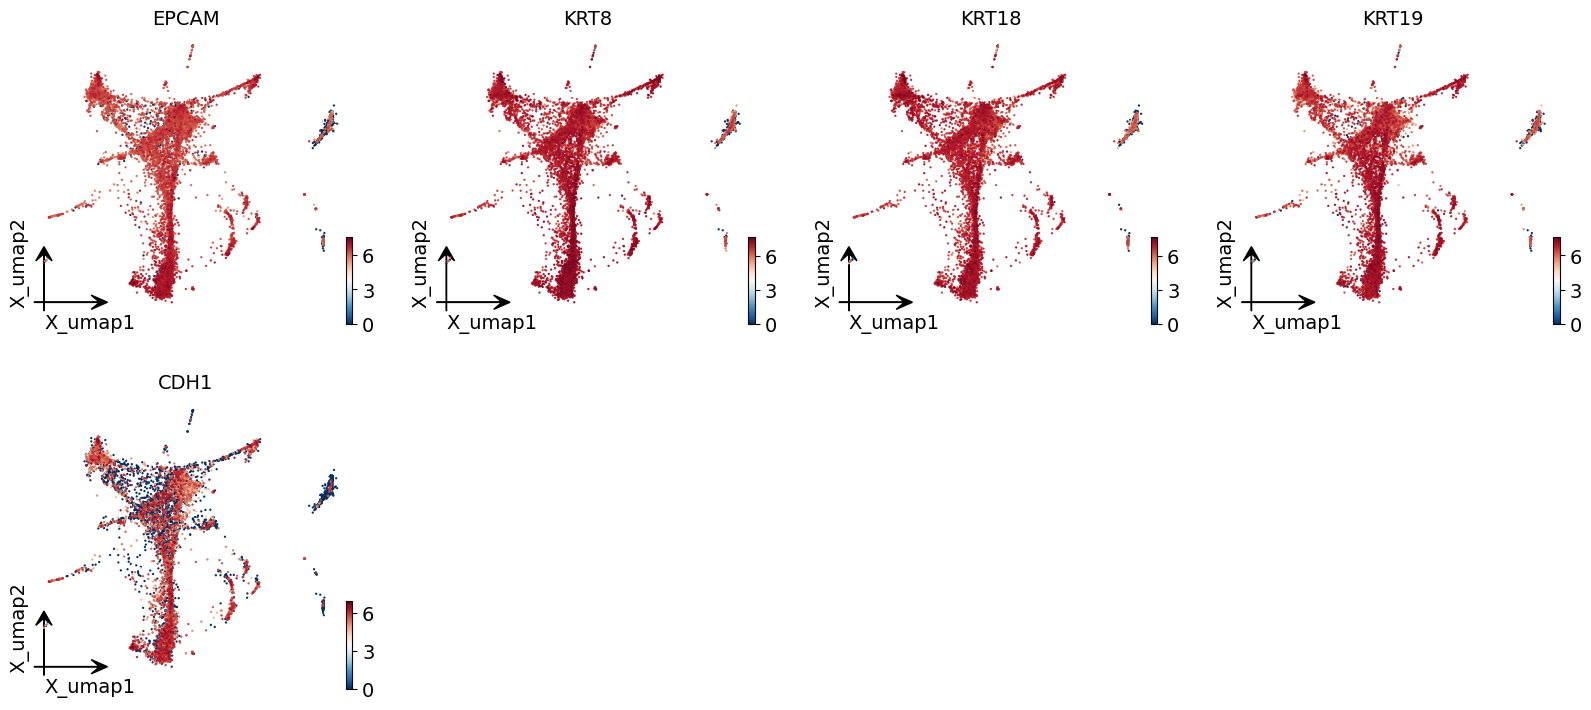

In [32]:
# 上皮谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['EPCAM', 'KRT8', 'KRT18', 'KRT19', 'CDH1'], # CLDN1
                frameon='small')

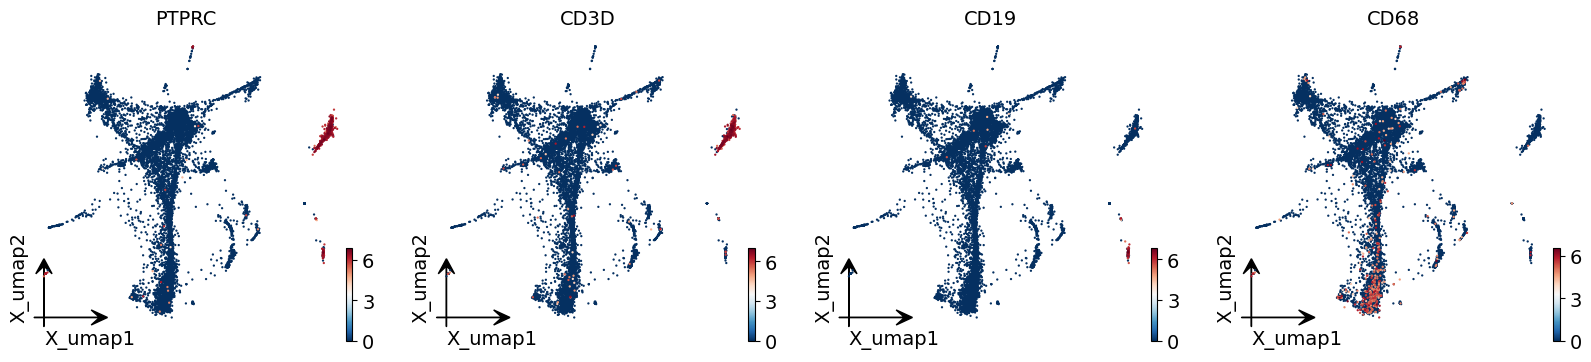

In [33]:
# 免疫谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC', 'CD3D', 'CD19', 'CD68'], 
                frameon='small')

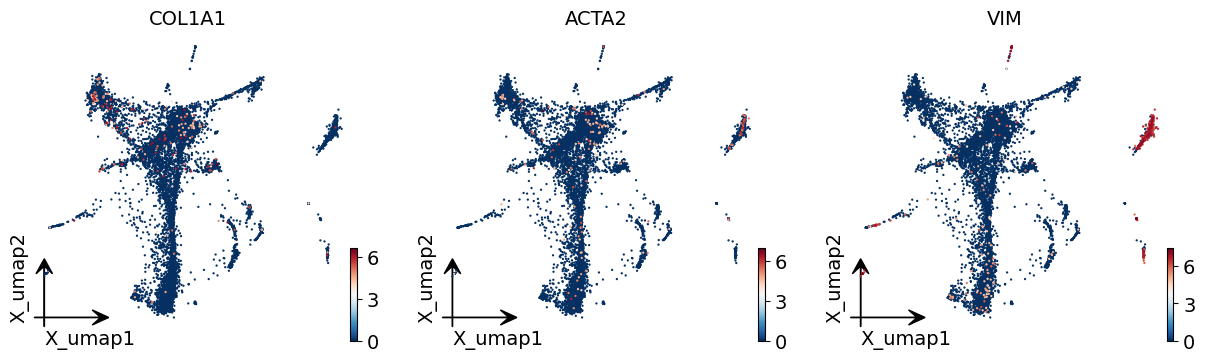

In [34]:
# 基质谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['COL1A1', 'ACTA2', 'VIM'],  # 'FAP'
                frameon='small')

## GPT自动注释

In [35]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:16)


{'0': ['RARRES2',
  'ATP5G1',
  'CYC1',
  'PPP1R1B',
  'MRPL12',
  'NUPR1',
  'TIMM13',
  'HES1',
  'GPX2',
  'STARD10'],
 '1': ['SLC26A3',
  'CEACAM7',
  'GUCA2A',
  'KRT20',
  'PLAC8',
  'SEPP1',
  'TMEM54',
  'TSPAN1',
  'CEACAM1',
  'FABP1'],
 '10': ['TYROBP',
  'HLA-DRB1',
  'LST1',
  'HLA-DPA1',
  'HLA-DQA1',
  'HLA-DRA',
  'HLA-DPB1',
  'AIF1',
  'LYZ',
  'CD74'],
 '11': ['SLC26A3',
  'CEACAM7',
  'LINC01133',
  'MS4A12',
  'PLAC8',
  'SEPP1',
  'C2orf88',
  'TMEM54',
  'CEACAM6',
  'AKAP12'],
 '2': ['WFDC2',
  'AGR2',
  'FCGBP',
  'KLK1',
  'LRRC26',
  'TFF3',
  'ZG16',
  'SPINK4',
  'ITLN1',
  'MUC2'],
 '3': ['PTPRC',
  'TMEM66',
  'HCST',
  'CD3E',
  'CD7',
  'CD52',
  'CCL5',
  'ARHGDIB',
  'SRGN',
  'CREM'],
 '4': ['RN7SK',
  'ARL14',
  'HBB',
  'RP11-70C1.1',
  'CA1',
  'RP11-6F2.5',
  'LINC00243',
  'RP11-467L13.7',
  'RP1-313I6.12'],
 '5': ['RARRES2',
  'GADD45GIP1',
  'NCL',
  'RP11-325P15.2',
  'SOX4',
  'NUPR1',
  'CD320',
  'CXCL3',
  'HES1',
  'SNRPD2'],
 '6': ['MT1

In [36]:
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='colon epithelial cells',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

Note: AGI API key found: returning the cell type annotations.
Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


{'0': 'enterocyte',
 '1': 'enterocyte',
 '10': 'immune cell',
 '11': 'enterocyte',
 '2': 'goblet cell',
 '3': 'T cell',
 '4': 'erythrocyte',
 '5': 'enterocyte progenitor',
 '6': 'enterocyte',
 '7': 'B cell',
 '8': 'enteroendocrine cell',
 '9': 'mast cell'}

In [37]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

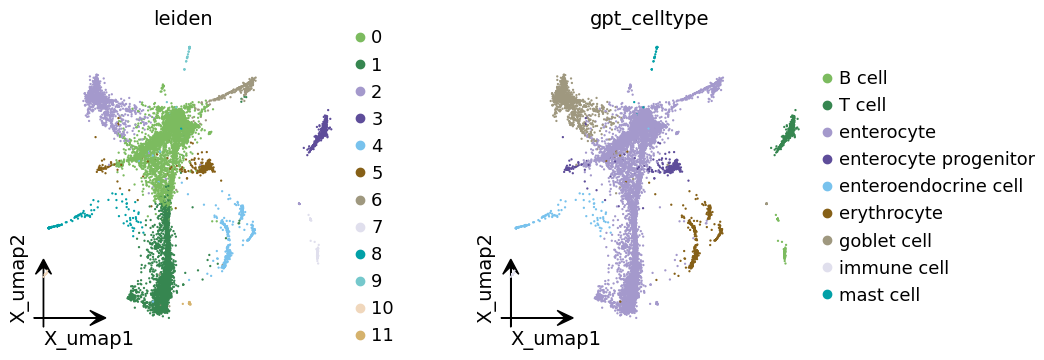

In [38]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [39]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)

gpt_celltype
enterocyte               65.094934
goblet cell              13.029785
T cell                    8.062629
erythrocyte               5.138127
enterocyte progenitor     3.743364
B cell                    2.546567
enteroendocrine cell      1.619725
mast cell                 0.422928
immune cell               0.341942
Name: proportion, dtype: float64
